## Imports

In [20]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.ndimage import gaussian_filter, rotate, shift
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
from skimage.transform import resize

## Configuration

In [21]:
VAL_SUBJECT = "TV4_20220204_sorted_UCL"
TEST_SUBJECT = "TV8_20220307_sorted_UCL"

CROP_SIZE = 80
DEGRADATION_GRID_SIZE = 96
SCALE_FACTOR = 1.5
FWHM_PX = SCALE_FACTOR
SIGMA_REF = FWHM_PX / (2 * np.sqrt(2 * np.log(2)))
SIGMA_MIN = SIGMA_REF * 0.7
SIGMA_MAX = SIGMA_REF * 1.3

CHANNELS = [8, 16, 32, 64]
EPOCHS = 80
TARGET_FRAMES_PER_SERIES = 30
USE_PHASE_BALANCED_SAMPLING = True

USE_GEOMETRIC_AUG = True
AUG_MAX_ROTATION_DEG = 5.0
AUG_MAX_TRANSLATION_PX = 3.0

USE_RANDOM_CONTRAST = True
CONTRAST_GAMMA_MIN = 0.8
CONTRAST_GAMMA_MAX = 1.2

USE_RANDOM_BIAS_FIELD = True
BIAS_FIELD_MAX_FRACTION = 0.15
BIAS_FIELD_GRID_SIZE = 4

MODEL_VARIANT = "L1_only"

assert 0 < CONTRAST_GAMMA_MIN <= CONTRAST_GAMMA_MAX
assert 0 <= BIAS_FIELD_MAX_FRACTION < 1
assert BIAS_FIELD_GRID_SIZE >= 2
assert DEGRADATION_GRID_SIZE >= CROP_SIZE
assert np.isclose(DEGRADATION_GRID_SIZE / SCALE_FACTOR, round(DEGRADATION_GRID_SIZE / SCALE_FACTOR))

BATCH_SIZE = 32
LEARNING_RATE = 1e-3
GRADIENT_LOSS_WEIGHT = 0.0
SEED = 0
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
NUM_WORKERS = 0
MAX_EPOCH_MINUTES = 15

OUTPUT_DIR = Path("Outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

EXPORT_PATH = OUTPUT_DIR / "tv_hr_crop_synthetic_lr_export.npz"
LUNG_MASK_EXPORT_PATH = OUTPUT_DIR / "tv_hr_crop_lung_mask_export.npz"
assert EXPORT_PATH.exists(), f"Export file not found at {EXPORT_PATH.resolve()}"
assert LUNG_MASK_EXPORT_PATH.exists(), (
    f"Lung-mask export not found at {LUNG_MASK_EXPORT_PATH.resolve()}. "
    "Run preprocessing.ipynb Step 9 before training."
)

RUN_NAME = "final_train"
CHECKPOINT_PATH = CHECKPOINT_DIR / f"{RUN_NAME}_best.pt"
HISTORY_PATH = OUTPUT_DIR / f"{RUN_NAME}_history.csv"

print("run:", RUN_NAME)
print("checkpoint:", CHECKPOINT_PATH)
print("history:", HISTORY_PATH)
print("random contrast:", USE_RANDOM_CONTRAST, (CONTRAST_GAMMA_MIN, CONTRAST_GAMMA_MAX))
print("random bias field:", USE_RANDOM_BIAS_FIELD, BIAS_FIELD_MAX_FRACTION)
print(f"loss: L1 + {GRADIENT_LOSS_WEIGHT:g} x gradient loss")
print("checkpoint selection metric: validation lung-mask PSNR")

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.use_deterministic_algorithms(True, warn_only=True)


run: final_train
checkpoint: Outputs\checkpoints\final_train_best.pt
history: Outputs\final_train_history.csv
random contrast: True (0.8, 1.2)
random bias field: True 0.15
loss: L1 + 0 x gradient loss
checkpoint selection metric: validation lung-mask PSNR


## Data Preparation

In [22]:
export_data = np.load(EXPORT_PATH, allow_pickle=True)
mask_data = np.load(LUNG_MASK_EXPORT_PATH, allow_pickle=True)
print("export arrays:", list(export_data.files))
print("lung-mask arrays:", list(mask_data.files))

included = export_data["included"].astype(bool)
assert len(mask_data["lung_mask"]) == len(included)
for key in ("subject", "slice", "dynamic"):
    assert np.array_equal(mask_data[key], export_data[key]), f"Lung-mask export is misaligned: {key}"

hr_frames = export_data["hr_frames"][included]
subject = export_data["subject"][included]
sl = export_data["slice"][included]
dyn = export_data["dynamic"][included]
phase_bin = export_data["phase_bin"][included]
lung_masks = mask_data["lung_mask"][included].astype(bool)
lung_mask_valid = mask_data["mask_valid"][included].astype(bool)

assert len(hr_frames) == len(lung_masks) == len(lung_mask_valid)
assert lung_masks.shape[1:] == hr_frames.shape[1:]
assert np.all(lung_masks[lung_mask_valid].reshape(lung_mask_valid.sum(), -1).sum(axis=1) > 0)

print("included frame count:", len(hr_frames))
print("frame shape:", hr_frames.shape[1:])
print("valid lung masks:", int(lung_mask_valid.sum()), "/", len(lung_mask_valid))


export arrays: ['hr_frames', 'lr_synth_frames', 'subject', 'slice', 'dynamic', 'phase_bin', 'phase_direction', 'anchor_row', 'anchor_col', 'crop_origin_row', 'crop_origin_col', 'included']
lung-mask arrays: ['lung_mask', 'mask_valid', 'included', 'subject', 'slice', 'dynamic']
included frame count: 7030
frame shape: (80, 80)
valid lung masks: 6969 / 7030


In [23]:
assert "echo" not in export_data.files
echoes_used = ["TE1"]
print("echo(es) used:", echoes_used)

echo(es) used: ['TE1']


In [24]:
all_subjects = sorted(set(subject.tolist()))
train_subjects = [s for s in all_subjects if s not in (VAL_SUBJECT, TEST_SUBJECT)]

# Split by subject to avoid temporal leakage.
train_mask = np.isin(subject, train_subjects)
val_mask = subject == VAL_SUBJECT
test_mask = subject == TEST_SUBJECT

train_idx = np.where(train_mask)[0]
val_idx = np.where(val_mask)[0]
test_idx = np.where(test_mask)[0]

print("train subjects:", train_subjects)
print("val subject:", VAL_SUBJECT)
print("test subject:", TEST_SUBJECT)
print("train/val/test frame counts:", len(train_idx), len(val_idx), len(test_idx))

for s in all_subjects:
    group = "val" if s == VAL_SUBJECT else "test" if s == TEST_SUBJECT else "train"
    print(f"  {s} ({group}): {int((subject == s).sum())}")


train subjects: ['TV1_20220222_sorted_UCL', 'TV2_20220222_sorted_UCL', 'TV3_20220208_sorted_UCL', 'TV5_20220307_sorted_UCL', 'TV6_20220307_sorted_UCL', 'TV7_20220315_sorted_UCL']
val subject: TV4_20220204_sorted_UCL
test subject: TV8_20220307_sorted_UCL
train/val/test frame counts: 4750 1140 1140
  TV1_20220222_sorted_UCL (train): 1140
  TV2_20220222_sorted_UCL (train): 760
  TV3_20220208_sorted_UCL (train): 950
  TV4_20220204_sorted_UCL (val): 1140
  TV5_20220307_sorted_UCL (train): 760
  TV6_20220307_sorted_UCL (train): 570
  TV7_20220315_sorted_UCL (train): 570
  TV8_20220307_sorted_UCL (test): 1140


In [25]:
def degrade_hr_to_lr(
    image,
    blur_sigma=SIGMA_REF,
    downsample_factor=SCALE_FACTOR,
    degradation_grid_size=DEGRADATION_GRID_SIZE,
):
    image = np.asarray(image, dtype=np.float64)
    assert image.ndim == 2 and image.shape[0] == image.shape[1], "Expected a square 2-D frame"
    size = image.shape[0]
    assert size <= degradation_grid_size

    total_pad = degradation_grid_size - size
    pad_before = total_pad // 2
    pad_after = total_pad - pad_before
    padded = np.pad(image, ((pad_before, pad_after), (pad_before, pad_after)), mode="edge")

    blur_mode = "constant"
    blurred = gaussian_filter(padded, sigma=blur_sigma, mode=blur_mode, cval=0.0)
    support = gaussian_filter(np.ones_like(padded), sigma=blur_sigma, mode=blur_mode, cval=0.0)
    blurred = blurred / np.maximum(support, 1e-3)

    small_size_exact = degradation_grid_size / downsample_factor
    assert np.isclose(small_size_exact, round(small_size_exact)), (
        "Degradation grid must divide exactly by the scale factor"
    )
    small_size = int(round(small_size_exact))
    downsampled = resize(
        blurred, (small_size, small_size), order=3, mode="edge",
        anti_aliasing=False, preserve_range=True,
    )
    upsampled = resize(
        downsampled, (degradation_grid_size, degradation_grid_size), order=3,
        mode="edge", anti_aliasing=False, preserve_range=True,
    )
    return upsampled[pad_before:pad_before + size, pad_before:pad_before + size]


def check_degradation_contract():
    assert int(DEGRADATION_GRID_SIZE / SCALE_FACTOR) == 64
    constant = degrade_hr_to_lr(np.ones((CROP_SIZE, CROP_SIZE), dtype=np.float64))
    assert constant.shape == (CROP_SIZE, CROP_SIZE)
    assert np.allclose(constant, 1.0, atol=1e-10)

    peaks = []
    for row in range(36, 45):
        impulse = np.zeros((CROP_SIZE, CROP_SIZE), dtype=np.float64)
        impulse[row, CROP_SIZE // 2] = 1.0
        degraded = degrade_hr_to_lr(impulse)
        assert np.isfinite(degraded).all()
        peaks.append(float(degraded.max()))
    assert np.allclose(peaks[:-3], peaks[3:], atol=1e-10), (
        "The exact 96→64→96 grid must repeat its three-row sampling phase"
    )
    return np.asarray(peaks)


degradation_probe_peaks = check_degradation_contract()
print("degradation grid: 80 padded to 96, resized 96→64→96, then cropped to 80")
print("degradation impulse peaks:", np.round(degradation_probe_peaks, 6).tolist())


def compute_percentile_scale(frames, subject, sl, low=1, high=99):
    scale = {}
    for key in set(zip(subject.tolist(), sl.tolist())):
        series = frames[(subject == key[0]) & (sl == key[1])]
        scale[key] = tuple(np.percentile(series, [low, high]))
    return scale


def normalise(img, lo, hi):
    return np.clip((img - lo) / max(hi - lo, 1e-6), 0.0, 1.0)


def denormalise(img, lo, hi):
    return img * (hi - lo) + lo


lr_frames_ref = np.stack([degrade_hr_to_lr(f, blur_sigma=SIGMA_REF) for f in hr_frames])
percentile_scale = compute_percentile_scale(lr_frames_ref, subject, sl)
print(f"percentile scaling computed for {len(percentile_scale)} subject/slice series")


degradation grid: 80 padded to 96, resized 96→64→96, then cropped to 80
degradation impulse peaks: [0.313567, 0.313567, 0.183021, 0.313567, 0.313567, 0.183021, 0.313567, 0.313567, 0.183021]
percentile scaling computed for 37 subject/slice series


## Augmentation


In [26]:
def augment_hr_geometric(image):
    angle = np.random.uniform(-AUG_MAX_ROTATION_DEG, AUG_MAX_ROTATION_DEG)
    dx = np.random.uniform(-AUG_MAX_TRANSLATION_PX, AUG_MAX_TRANSLATION_PX)
    dy = np.random.uniform(-AUG_MAX_TRANSLATION_PX, AUG_MAX_TRANSLATION_PX)
    rotated = rotate(image, angle, reshape=False, order=3, mode="nearest")
    return shift(rotated, shift=(dy, dx), order=3, mode="nearest")


def synthesize_random_bias_field(shape):
    coarse = np.random.normal(size=(BIAS_FIELD_GRID_SIZE, BIAS_FIELD_GRID_SIZE))
    field = resize(
        coarse,
        shape,
        order=3,
        mode="reflect",
        anti_aliasing=False,
        preserve_range=True,
    )
    field -= field.mean()
    max_abs = np.max(np.abs(field))
    if max_abs > 0:
        field /= max_abs
    amplitude = np.random.uniform(0.0, BIAS_FIELD_MAX_FRACTION)
    return 1.0 + amplitude * field


def augment_hr_intensity(image, lo, hi):
    scale = max(hi - lo, 1e-6)
    image_n = np.clip((image - lo) / scale, 0.0, 1.0)

    if USE_RANDOM_CONTRAST:
        gamma = np.random.uniform(CONTRAST_GAMMA_MIN, CONTRAST_GAMMA_MAX)
        image_n = image_n ** gamma

    if USE_RANDOM_BIAS_FIELD:
        image_n = image_n * synthesize_random_bias_field(image_n.shape)

    return denormalise(np.clip(image_n, 0.0, 1.0), lo, hi)


def augment_hr_training(image, lo, hi):
    if USE_GEOMETRIC_AUG:
        image = augment_hr_geometric(image)
    if USE_RANDOM_CONTRAST or USE_RANDOM_BIAS_FIELD:
        image = augment_hr_intensity(image, lo, hi)
    return image


In [27]:
# Intensity augmentations are defined above and require no real-data calibration.


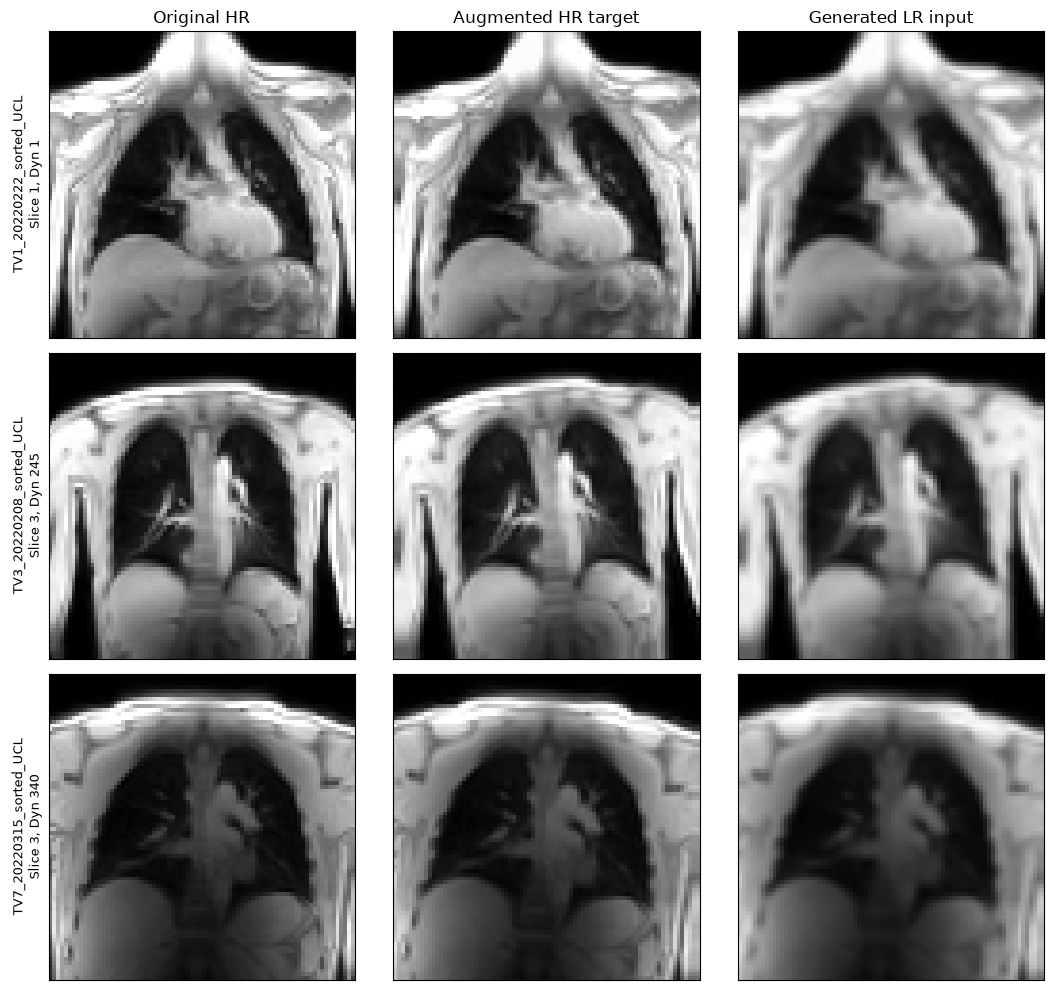

In [28]:
frame_indices = train_idx[np.linspace(0, len(train_idx) - 1, 3, dtype=int)]
rng_state = np.random.get_state()
fig, axes = plt.subplots(3, 3, figsize=(11, 10))

for row, idx in enumerate(frame_indices):
    hr = hr_frames[idx]
    lo, hi = percentile_scale[(subject[idx], sl[idx])]
    augmented_hr = augment_hr_training(hr.copy(), lo, hi)
    augmented_lr = degrade_hr_to_lr(augmented_hr, blur_sigma=SIGMA_REF)
    images = [normalise(hr, lo, hi), normalise(augmented_hr, lo, hi), normalise(augmented_lr, lo, hi)]
    titles = ["Original HR", "Augmented HR target", "Generated LR input"]

    for col, (image, title) in enumerate(zip(images, titles)):
        axes[row, col].imshow(image, cmap="gray", vmin=0, vmax=1)
        if row == 0:
            axes[row, col].set_title(title)
        axes[row, col].set_xticks([])
        axes[row, col].set_yticks([])
    axes[row, 0].set_ylabel(f"{subject[idx]}\nSlice {sl[idx]}, Dyn {dyn[idx]}", fontsize=9)

np.random.set_state(rng_state)
plt.tight_layout()
plt.show()


## Datasets and Sampling

In [29]:
class SpatialPairDataset(torch.utils.data.Dataset):
    def __init__(self, indices, sigma_min, sigma_max, fixed_sigma=None, augment=False):
        self.indices = indices
        self.sigma_min = sigma_min
        self.sigma_max = sigma_max
        self.fixed_sigma = fixed_sigma
        self.augment = augment

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        idx = self.indices[i]
        hr = hr_frames[idx]
        lo, hi = percentile_scale[(subject[idx], sl[idx])]

        if self.augment:
            hr = augment_hr_training(hr, lo, hi)

        sigma = self.fixed_sigma if self.fixed_sigma is not None else np.random.uniform(self.sigma_min, self.sigma_max)
        lr = degrade_hr_to_lr(hr, blur_sigma=sigma)

        hr_t = torch.from_numpy(normalise(hr, lo, hi)).float().unsqueeze(0)
        lr_t = torch.from_numpy(normalise(lr, lo, hi)).float().unsqueeze(0)
        mask_t = torch.from_numpy(lung_masks[idx]).bool().unsqueeze(0)
        valid_t = torch.tensor(lung_mask_valid[idx], dtype=torch.bool)
        return lr_t, hr_t, mask_t, valid_t


In [30]:
def sample_series_positions(positions, phase_values, target_n, rng):
    n = min(target_n, len(positions))
    valid = ~np.isnan(phase_values)
    if valid.sum() < 2:
        return rng.choice(positions, size=n, replace=False)

    bins = {b: positions[valid][phase_values[valid] == b] for b in np.unique(phase_values[valid])}
    if (~valid).any():
        bins["unknown"] = positions[~valid]

    quotas = {k: 0 for k in bins}
    active = set(bins)
    remaining = n

    while remaining > 0 and active:
        share = max(1, remaining // len(active))
        for key in list(active):
            take = min(share, len(bins[key]) - quotas[key], remaining)
            quotas[key] += take
            remaining -= take
            if quotas[key] >= len(bins[key]):
                active.discard(key)
            if remaining == 0:
                break

    chosen = [rng.choice(bins[k], size=quotas[k], replace=False) for k in bins if quotas[k] > 0]
    return np.concatenate(chosen)


class PhaseBalancedEpochSampler(torch.utils.data.Sampler):
    def __init__(self, local_subject, local_sl, local_phase, target_per_series, seed):
        self.local_subject = local_subject
        self.local_sl = local_sl
        self.local_phase = local_phase
        self.target_per_series = target_per_series
        self.rng = np.random.default_rng(seed)
        self.series_keys = sorted(set(zip(local_subject.tolist(), local_sl.tolist())))
        self.series_sizes = {
            key: int(((local_subject == key[0]) & (local_sl == key[1])).sum())
            for key in self.series_keys
        }
        self.last_counts = {}

    def __iter__(self):
        chosen_per_series = []
        for key in self.series_keys:
            mask = (self.local_subject == key[0]) & (self.local_sl == key[1])
            positions = np.where(mask)[0]
            phases = self.local_phase[positions]
            chosen = sample_series_positions(positions, phases, self.target_per_series, self.rng)
            chosen_per_series.append(chosen)
            self.last_counts[key] = len(chosen)

        all_positions = np.concatenate(chosen_per_series)
        self.rng.shuffle(all_positions)
        return iter(all_positions.tolist())

    def __len__(self):
        return sum(min(self.target_per_series, n) for n in self.series_sizes.values())

In [31]:
pin_memory = DEVICE == "cuda"
use_training_augmentation = USE_GEOMETRIC_AUG or USE_RANDOM_CONTRAST or USE_RANDOM_BIAS_FIELD
train_ds = SpatialPairDataset(train_idx, SIGMA_MIN, SIGMA_MAX, augment=use_training_augmentation)
val_ds = SpatialPairDataset(val_idx, SIGMA_MIN, SIGMA_MAX, fixed_sigma=SIGMA_REF)

train_sampler = PhaseBalancedEpochSampler(subject[train_idx], sl[train_idx], phase_bin[train_idx], TARGET_FRAMES_PER_SERIES, SEED)

if USE_PHASE_BALANCED_SAMPLING:
    train_loader = torch.utils.data.DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=train_sampler, num_workers=NUM_WORKERS, pin_memory=pin_memory)
else:
    train_loader = torch.utils.data.DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=pin_memory)

val_loader = torch.utils.data.DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=pin_memory)

sampling_mode = "phase-balanced" if USE_PHASE_BALANCED_SAMPLING else "full-frame shuffle"
print("training sampling:", sampling_mode)
print("training augmentations: geometric, contrast, bias field =", USE_GEOMETRIC_AUG, USE_RANDOM_CONTRAST, USE_RANDOM_BIAS_FIELD)
print("available training frames:", len(train_idx))
if USE_PHASE_BALANCED_SAMPLING:
    print("phase-balanced frames per epoch:", len(train_sampler))


training sampling: phase-balanced
training augmentations: geometric, contrast, bias field = True True True
available training frames: 4750
phase-balanced frames per epoch: 750


## Model

In [32]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.GroupNorm(min(8, out_ch), out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.GroupNorm(min(8, out_ch), out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)


class UNet(nn.Module):
    def __init__(self, channels):
        super().__init__()
        c1, c2, c3, c4 = channels
        self.pool = nn.MaxPool2d(2)

        self.enc1 = ConvBlock(1, c1)
        self.enc2 = ConvBlock(c1, c2)
        self.enc3 = ConvBlock(c2, c3)
        self.enc4 = ConvBlock(c3, c4)
        self.bottleneck = ConvBlock(c4, c4)

        self.up4 = nn.ConvTranspose2d(c4, c4, 2, stride=2)
        self.dec4 = ConvBlock(c4 + c4, c3)
        self.up3 = nn.ConvTranspose2d(c3, c3, 2, stride=2)
        self.dec3 = ConvBlock(c3 + c3, c2)
        self.up2 = nn.ConvTranspose2d(c2, c2, 2, stride=2)
        self.dec2 = ConvBlock(c2 + c2, c1)
        self.up1 = nn.ConvTranspose2d(c1, c1, 2, stride=2)
        self.dec1 = ConvBlock(c1 + c1, c1)
        self.out_conv = nn.Conv2d(c1, 1, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b = self.bottleneck(self.pool(e4))

        d4 = self.dec4(torch.cat([self.up4(b), e4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.out_conv(d1)


torch.manual_seed(SEED)
model = UNet(CHANNELS).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("channels:", CHANNELS)
print("trainable parameters:", n_params)

channels: [8, 16, 32, 64]
trainable parameters: 232537


## Training Loop

In [33]:
def psnr_batch(pred, target):
    pred_np = pred.detach().cpu().numpy()
    target_np = target.detach().cpu().numpy()
    scores = [peak_signal_noise_ratio(target_np[i, 0], pred_np[i, 0], data_range=1.0) for i in range(pred_np.shape[0])]
    return float(np.mean(scores))


def ssim_batch(pred, target):
    pred_np = pred.detach().cpu().numpy()
    target_np = target.detach().cpu().numpy()
    scores = [structural_similarity(target_np[i, 0], pred_np[i, 0], data_range=1.0) for i in range(pred_np.shape[0])]
    return float(np.mean(scores))


def lung_metrics(pred, target, masks, valid):
    pred_np = pred.detach().cpu().numpy()[:, 0]
    target_np = target.detach().cpu().numpy()[:, 0]
    mask_np = masks.detach().cpu().numpy()[:, 0].astype(bool)
    valid_np = valid.detach().cpu().numpy().astype(bool)
    psnr_scores, ssim_scores = [], []
    for pred_i, target_i, mask_i, valid_i in zip(pred_np, target_np, mask_np, valid_np):
        if not valid_i or not mask_i.any():
            continue
        mse = float(np.mean((pred_i[mask_i] - target_i[mask_i]) ** 2))
        psnr_scores.append(float("inf") if mse == 0 else -10.0 * np.log10(mse))
        _, ssim_map = structural_similarity(target_i, pred_i, data_range=1.0, full=True)
        ssim_scores.append(float(ssim_map[mask_i].mean()))
    return psnr_scores, ssim_scores


def gradient_loss(prediction, target):
    pred_dx = prediction[:, :, :, 1:] - prediction[:, :, :, :-1]
    target_dx = target[:, :, :, 1:] - target[:, :, :, :-1]
    pred_dy = prediction[:, :, 1:, :] - prediction[:, :, :-1, :]
    target_dy = target[:, :, 1:, :] - target[:, :, :-1, :]
    return 0.5 * (F.l1_loss(pred_dx, target_dx) + F.l1_loss(pred_dy, target_dy))


def reconstruction_loss(pred_residual, target_residual):
    l1 = F.l1_loss(pred_residual, target_residual)
    gradient = gradient_loss(pred_residual, target_residual)
    loss = l1 + GRADIENT_LOSS_WEIGHT * gradient
    return loss, l1, gradient


def run_train_epoch(model, loader, optimizer):
    model.train()
    total = {"loss": 0.0, "l1": 0.0, "gradient": 0.0}
    n = 0

    for lr, hr, _mask, _valid in loader:
        lr, hr = lr.to(DEVICE), hr.to(DEVICE)
        pred_residual = model(lr)
        loss, l1, gradient = reconstruction_loss(pred_residual, hr - lr)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        bs = lr.size(0)
        total["loss"] += loss.item() * bs
        total["l1"] += l1.item() * bs
        total["gradient"] += gradient.item() * bs
        n += bs

    return {key: value / n for key, value in total.items()}


def validate(model, loader):
    model.eval()
    total = {"loss": 0.0, "l1": 0.0, "gradient": 0.0, "psnr": 0.0, "ssim": 0.0, "input_psnr": 0.0, "input_ssim": 0.0}
    lung_psnr_scores, lung_ssim_scores = [], []
    n = 0

    with torch.no_grad():
        for lr, hr, mask, valid in loader:
            lr, hr = lr.to(DEVICE), hr.to(DEVICE)
            pred_residual = model(lr)
            loss, l1, gradient = reconstruction_loss(pred_residual, hr - lr)
            prediction = (lr + pred_residual).clamp(0.0, 1.0)

            bs = lr.size(0)
            total["loss"] += loss.item() * bs
            total["l1"] += l1.item() * bs
            total["gradient"] += gradient.item() * bs
            total["psnr"] += psnr_batch(prediction, hr) * bs
            total["ssim"] += ssim_batch(prediction, hr) * bs
            total["input_psnr"] += psnr_batch(lr, hr) * bs
            total["input_ssim"] += ssim_batch(lr, hr) * bs
            batch_lung_psnr, batch_lung_ssim = lung_metrics(prediction, hr, mask, valid)
            lung_psnr_scores.extend(batch_lung_psnr)
            lung_ssim_scores.extend(batch_lung_ssim)
            n += bs

    metrics = {key: value / n for key, value in total.items()}
    assert lung_psnr_scores, "Validation has no valid lung masks"
    metrics["lung_psnr"] = float(np.mean(lung_psnr_scores))
    metrics["lung_ssim"] = float(np.mean(lung_ssim_scores))
    metrics["lung_frames"] = len(lung_psnr_scores)
    return metrics


def make_checkpoint(epoch, val_metrics, model):
    return {
        "format_version": 2,
        "checkpoint_type": "best_validation_lung_psnr",
        "state_dict": model.state_dict(),
        "run_name": RUN_NAME,
        "model_variant": MODEL_VARIANT,
        "channels": list(CHANNELS),
        "epoch": int(epoch),
        "selection_metric": "lung_psnr",
        "selection_value": float(val_metrics["lung_psnr"]),
        "val_metrics": {key: float(value) for key, value in val_metrics.items()},
        "seed": int(SEED),
        "train_subjects": list(train_subjects),
        "val_subject": VAL_SUBJECT,
        "test_subject": TEST_SUBJECT,
        "crop_size": int(CROP_SIZE),
        "degradation_grid_size": int(DEGRADATION_GRID_SIZE),
        "scale_factor": float(SCALE_FACTOR),
        "sigma_ref": float(SIGMA_REF),
        "sigma_min": float(SIGMA_MIN),
        "sigma_max": float(SIGMA_MAX),
        "learning_rate": float(LEARNING_RATE),
        "loss_name": "l1_plus_finite_difference_gradient",
        "gradient_loss_weight": float(GRADIENT_LOSS_WEIGHT),
        "use_geometric_augmentation": bool(USE_GEOMETRIC_AUG),
        "use_random_contrast": bool(USE_RANDOM_CONTRAST),
        "use_random_bias_field": bool(USE_RANDOM_BIAS_FIELD),
    }


def train_model(model, train_loader, val_loader, epochs, learning_rate, checkpoint_path, history_path):
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    best_val_lung_psnr = -float("inf")
    history = []

    for epoch in range(epochs):
        epoch_start = time.time()
        train_metrics = run_train_epoch(model, train_loader, optimizer)
        val_metrics = validate(model, val_loader)
        epoch_minutes = (time.time() - epoch_start) / 60

        print(
            f"epoch {epoch + 1}/{epochs}  train_loss={train_metrics['loss']:.4f}  "
            f"train_l1={train_metrics['l1']:.4f}  train_gradient={train_metrics['gradient']:.4f}  "
            f"val_loss={val_metrics['loss']:.4f}  val_l1={val_metrics['l1']:.4f}  "
            f"val_gradient={val_metrics['gradient']:.4f}  "
            f"val_psnr={val_metrics['psnr']:.2f}  val_ssim={val_metrics['ssim']:.4f}  "
            f"lung_psnr={val_metrics['lung_psnr']:.2f}  lung_ssim={val_metrics['lung_ssim']:.4f}  "
            f"input_psnr={val_metrics['input_psnr']:.2f}  input_ssim={val_metrics['input_ssim']:.4f}  "
            f"epoch_time={epoch_minutes:.1f}min"
        )

        if epoch_minutes > MAX_EPOCH_MINUTES:
            print(f"warning: epoch exceeded {MAX_EPOCH_MINUTES} minutes")

        if val_metrics["lung_psnr"] > best_val_lung_psnr:
            best_val_lung_psnr = val_metrics["lung_psnr"]
            torch.save(make_checkpoint(epoch + 1, val_metrics, model), checkpoint_path)

        history.append({
            "epoch": epoch + 1,
            "run_name": RUN_NAME,
            "train_loss": train_metrics["loss"],
            "train_l1": train_metrics["l1"],
            "train_gradient": train_metrics["gradient"],
            "gradient_loss_weight": GRADIENT_LOSS_WEIGHT,
            "epoch_minutes": epoch_minutes,
            "use_geometric_augmentation": USE_GEOMETRIC_AUG,
            "use_random_contrast": USE_RANDOM_CONTRAST,
            "use_random_bias_field": USE_RANDOM_BIAS_FIELD,
            **val_metrics,
        })

    pd.DataFrame(history).to_csv(history_path, index=False)
    return history


In [34]:
history = train_model(
    model,
    train_loader,
    val_loader,
    EPOCHS,
    LEARNING_RATE,
    CHECKPOINT_PATH,
    HISTORY_PATH,
)

print(f"saved best validation lung-PSNR checkpoint to {CHECKPOINT_PATH}")


epoch 1/80  train_loss=0.0661  train_l1=0.0661  train_gradient=0.0668  val_loss=0.0296  val_l1=0.0296  val_gradient=0.0316  val_psnr=27.45  val_ssim=0.9176  lung_psnr=30.47  lung_ssim=0.9170  input_psnr=29.36  input_ssim=0.9528  epoch_time=0.2min
epoch 2/80  train_loss=0.0266  train_l1=0.0266  train_gradient=0.0273  val_loss=0.0238  val_l1=0.0238  val_gradient=0.0258  val_psnr=28.78  val_ssim=0.9424  lung_psnr=32.98  lung_ssim=0.9419  input_psnr=29.36  input_ssim=0.9528  epoch_time=0.3min
epoch 3/80  train_loss=0.0224  train_l1=0.0224  train_gradient=0.0238  val_loss=0.0216  val_l1=0.0216  val_gradient=0.0243  val_psnr=29.20  val_ssim=0.9499  lung_psnr=34.17  lung_ssim=0.9544  input_psnr=29.36  input_ssim=0.9528  epoch_time=0.3min
epoch 4/80  train_loss=0.0208  train_l1=0.0208  train_gradient=0.0226  val_loss=0.0200  val_l1=0.0200  val_gradient=0.0235  val_psnr=29.45  val_ssim=0.9539  lung_psnr=34.85  lung_ssim=0.9589  input_psnr=29.36  input_ssim=0.9528  epoch_time=0.3min
epoch 5/80  

## Evaluation

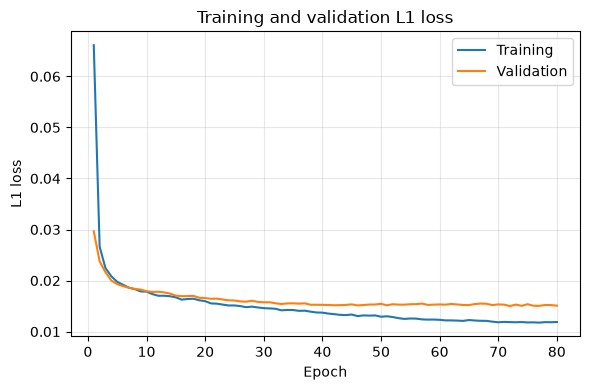

In [35]:
history_df = pd.DataFrame(history)

plt.figure(figsize=(6, 4))
plt.plot(history_df["epoch"], history_df["train_l1"], label="Training")
plt.plot(history_df["epoch"], history_df["l1"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("L1 loss")
plt.title("Training and validation L1 loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [36]:
evaluation_checkpoint = CHECKPOINT_PATH
evaluation_name = CHECKPOINT_PATH.stem

if evaluation_checkpoint.exists():
    test_ds_raw = SpatialPairDataset(test_idx, SIGMA_MIN, SIGMA_MAX, fixed_sigma=SIGMA_REF)
    test_loader_raw = torch.utils.data.DataLoader(
        test_ds_raw, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=pin_memory,
    )

    torch.manual_seed(SEED)
    test_model = UNet(CHANNELS).to(DEVICE)
    checkpoint = torch.load(evaluation_checkpoint, map_location=DEVICE, weights_only=True)
    assert isinstance(checkpoint, dict) and "state_dict" in checkpoint, (
        "Legacy bare state_dict rejected. Retrain so checkpoint provenance is recorded."
    )
    assert checkpoint.get("run_name") == RUN_NAME
    assert list(checkpoint.get("channels", [])) == list(CHANNELS)
    assert checkpoint.get("degradation_grid_size") == DEGRADATION_GRID_SIZE
    assert np.isclose(checkpoint.get("scale_factor"), SCALE_FACTOR)
    test_model.load_state_dict(checkpoint["state_dict"], strict=True)
    test_model.eval()

    raw_lr_images, pred_images, hr_images = [], [], []
    raw_baseline_psnr, model_psnr = [], []
    raw_baseline_ssim, model_ssim = [], []
    lung_baseline_psnr, lung_model_psnr = [], []
    lung_baseline_ssim, lung_model_ssim = [], []
    test_metadata = []

    with torch.no_grad():
        for raw_lr, hr, mask, valid in test_loader_raw:
            raw_lr, hr = raw_lr.to(DEVICE), hr.to(DEVICE)
            prediction = (raw_lr + test_model(raw_lr)).clamp(0.0, 1.0)

            raw_lr_np = raw_lr[:, 0].cpu().numpy()
            pred_np = prediction[:, 0].cpu().numpy()
            hr_np = hr[:, 0].cpu().numpy()
            raw_lr_images.append(raw_lr_np)
            pred_images.append(pred_np)
            hr_images.append(hr_np)

            base_lp, base_ls = lung_metrics(raw_lr, hr, mask, valid)
            model_lp, model_ls = lung_metrics(prediction, hr, mask, valid)
            lung_baseline_psnr.extend(base_lp)
            lung_baseline_ssim.extend(base_ls)
            lung_model_psnr.extend(model_lp)
            lung_model_ssim.extend(model_ls)

            for raw_lr_i, pred_i, hr_i in zip(raw_lr_np, pred_np, hr_np):
                raw_baseline_psnr.append(peak_signal_noise_ratio(hr_i, raw_lr_i, data_range=1.0))
                model_psnr.append(peak_signal_noise_ratio(hr_i, pred_i, data_range=1.0))
                raw_baseline_ssim.append(structural_similarity(hr_i, raw_lr_i, data_range=1.0))
                model_ssim.append(structural_similarity(hr_i, pred_i, data_range=1.0))

    raw_lr_images = np.concatenate(raw_lr_images)
    pred_images = np.concatenate(pred_images)
    hr_images = np.concatenate(hr_images)

    test_results = pd.DataFrame({
        "slice": sl[test_idx],
        "dynamic": dyn[test_idx],
        "baseline_psnr": raw_baseline_psnr,
        "model_psnr": model_psnr,
        "psnr_gain": np.array(model_psnr) - np.array(raw_baseline_psnr),
        "baseline_ssim": raw_baseline_ssim,
        "model_ssim": model_ssim,
        "ssim_gain": np.array(model_ssim) - np.array(raw_baseline_ssim),
    })
    test_results.to_csv(OUTPUT_DIR / f"{evaluation_name}_test_metrics.csv", index=False)

    print("evaluation:", evaluation_name)
    print("checkpoint metadata:", {k: checkpoint[k] for k in ["run_name", "epoch", "selection_metric", "selection_value"]})
    print("test subject:", TEST_SUBJECT)
    print(f"whole-crop LR PSNR/SSIM: {np.mean(raw_baseline_psnr):.2f} dB / {np.mean(raw_baseline_ssim):.4f}")
    print(f"whole-crop model PSNR/SSIM: {np.mean(model_psnr):.2f} dB / {np.mean(model_ssim):.4f}")
    print(f"lung-mask LR PSNR/SSIM: {np.mean(lung_baseline_psnr):.2f} dB / {np.mean(lung_baseline_ssim):.4f}")
    print(f"lung-mask model PSNR/SSIM: {np.mean(lung_model_psnr):.2f} dB / {np.mean(lung_model_ssim):.4f}")
else:
    print(f"checkpoint not found: {evaluation_checkpoint}")


evaluation: final_train_best
checkpoint metadata: {'run_name': 'final_train', 'epoch': 38, 'selection_metric': 'lung_psnr', 'selection_value': 37.37340050958074}
test subject: TV8_20220307_sorted_UCL
whole-crop LR PSNR/SSIM: 27.53 dB / 0.9403
whole-crop model PSNR/SSIM: 29.90 dB / 0.9644
lung-mask LR PSNR/SSIM: 31.46 dB / 0.9537
lung-mask model PSNR/SSIM: 35.34 dB / 0.9749


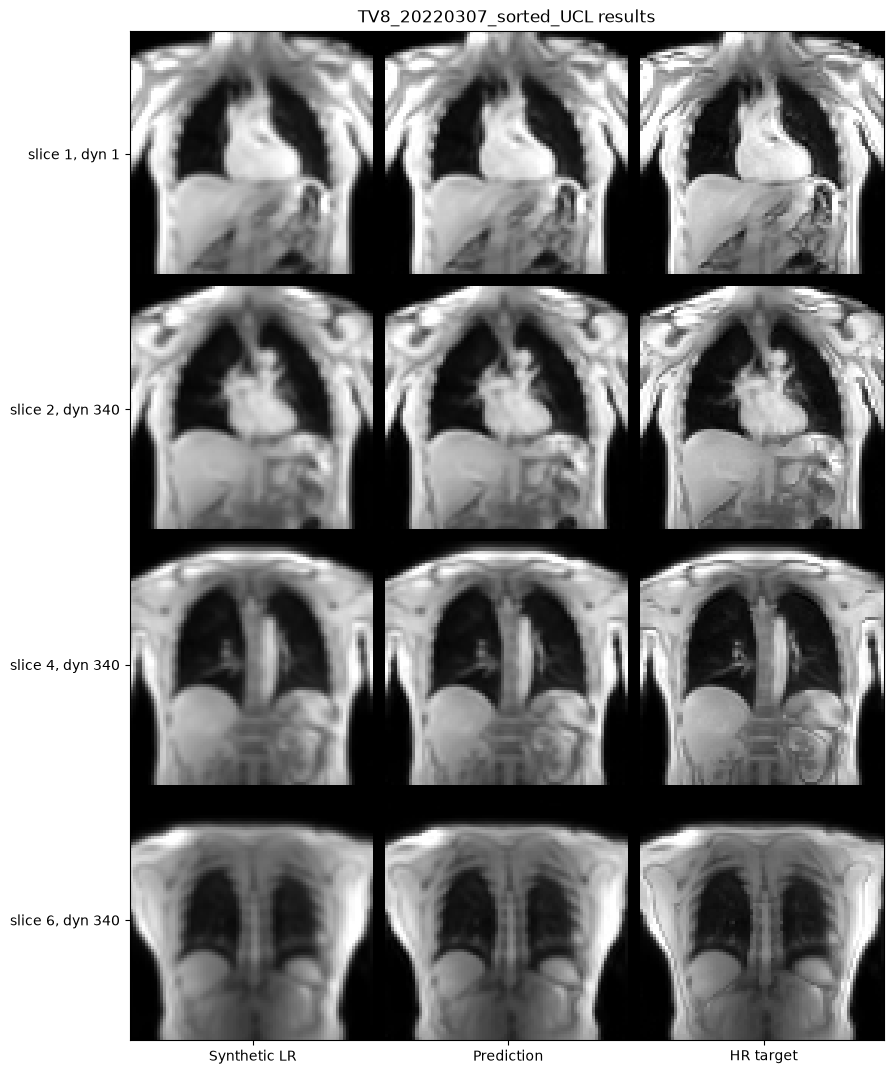

In [37]:
if evaluation_checkpoint.exists():
    frame_positions = np.linspace(0, len(test_idx) - 1, min(4, len(test_idx)), dtype=int)
    spacer = np.zeros((CROP_SIZE, 4), dtype=np.float32)
    rows = []

    for pos in frame_positions:
        rows.append(np.concatenate([raw_lr_images[pos],spacer,pred_images[pos],spacer,hr_images[pos],], axis=1))

    row_spacer = np.zeros((4, rows[0].shape[1]), dtype=np.float32)
    grid_parts = []
    for i, row in enumerate(rows):
        if i:
            grid_parts.append(row_spacer)
        grid_parts.append(row)
    frame_grid = np.concatenate(grid_parts, axis=0)

    column_width = CROP_SIZE + 4
    x_ticks = [CROP_SIZE / 2, column_width + CROP_SIZE / 2, 2 * column_width + CROP_SIZE / 2]
    y_ticks = [i * (CROP_SIZE + 4) + CROP_SIZE / 2 for i in range(len(frame_positions))]
    y_labels = [f"slice {sl[test_idx[pos]]}, dyn {dyn[test_idx[pos]]}" for pos in frame_positions]

    plt.figure(figsize=(9, 3 * len(frame_positions)))
    plt.imshow(frame_grid, cmap="gray", vmin=0, vmax=1)
    plt.xticks(x_ticks, ["Synthetic LR", "Prediction", "HR target"])
    plt.yticks(y_ticks, y_labels)
    plt.title(f"{TEST_SUBJECT} results")
    plt.tight_layout()
    plt.show()


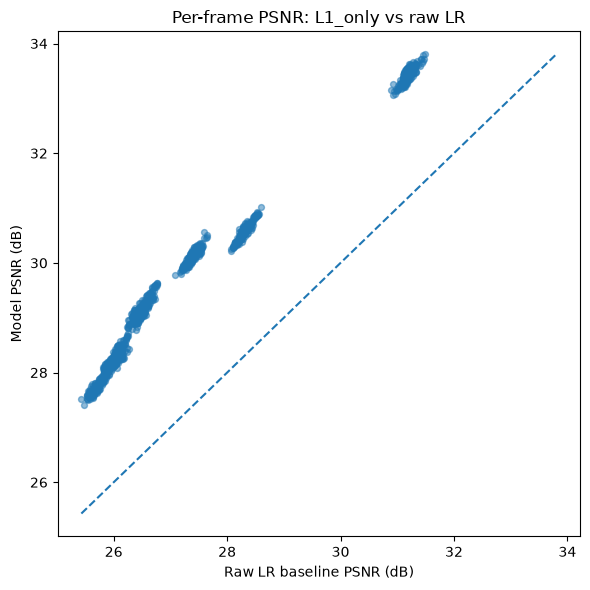

In [38]:
if evaluation_checkpoint.exists():
    lower = min(
        test_results["baseline_psnr"].min(),
        test_results["model_psnr"].min(),
    )
    upper = max(
        test_results["baseline_psnr"].max(),
        test_results["model_psnr"].max(),
    )

    plt.figure(figsize=(6, 6))
    plt.scatter(
        test_results["baseline_psnr"],
        test_results["model_psnr"],
        alpha=0.5,
        s=18,
    )
    plt.plot([lower, upper], [lower, upper], linestyle="--")
    plt.xlabel("Raw LR baseline PSNR (dB)")
    plt.ylabel("Model PSNR (dB)")
    plt.title(f"Per-frame PSNR: {MODEL_VARIANT} vs raw LR")
    plt.tight_layout()
    plt.show()